**Project Short Introduction**

This project is based on the Bank Marketing Dataset. The objective of the project is to predict whether a customer will subscribe to a term deposit or not using an Artificial Neural Network (ANN).

Target Classes
- Class 0 = Customer will NOT subscribe to the term deposit
- Class 1 = Customer WILL subscribe to the term deposit

The ANN model is trained using customer banking information and marketing campaign data. After training, the model performance is evaluated using multiple evaluation metrics and visualizations.

**Import Libraries**

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,

)

**Load Dataset**

In [29]:
df = pd.read_csv('/content/drive/MyDrive/Bank Marketing Dataset/bank-full.csv')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


**Data Understanding**

In [30]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [31]:
print("Class 0 = Customer will NOT subscribe to term deposit")
print("Class 1 = Customer WILL subscribe to term deposit")

Class 0 = Customer will NOT subscribe to term deposit
Class 1 = Customer WILL subscribe to term deposit


**Handle Categorical Variables**

In [66]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

**Data Visualization**

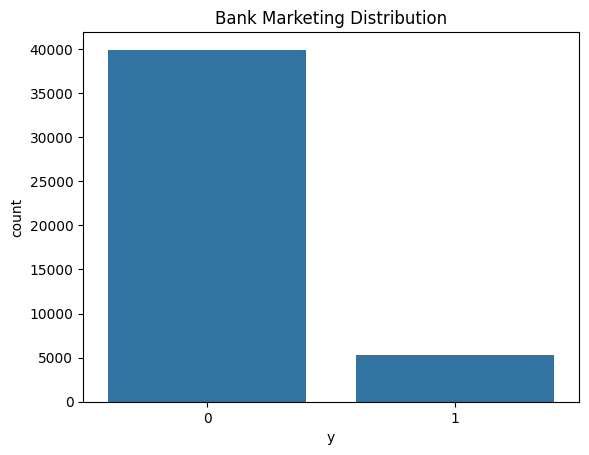

In [67]:
sns.countplot(x='y', data=df)
plt.title("Bank Marketing Distribution")
plt.show()

New counts:
 y
1    39922
0    39922
Name: count, dtype: int64


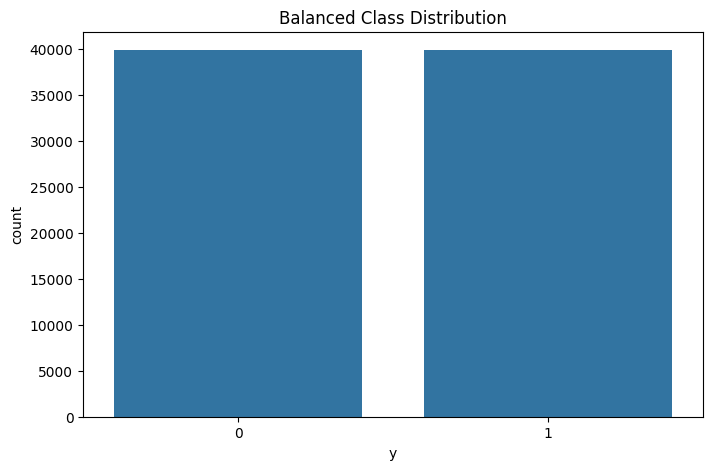

In [69]:

df_0 = df[df['y'] == 0]
df_1 = df[df['y'] == 1]

# Upsample the minority class
df_1_upsampled = df_1.sample(len(df_0), replace=True, random_state=42)

# Combine into a BRAND NEW variable
df_balanced = pd.concat([df_0, df_1_upsampled]).sample(frac=1).reset_index(drop=True)

# PROOF: Check the numbers in the console
print("New counts:\n", df_balanced['y'].value_counts())

# THE GRAPH: Make sure 'data' is set to df_balanced
plt.figure(figsize=(8,5))
sns.countplot(data=df_balanced, x='y') # <-- This MUST be df_balanced
plt.title("Balanced Class Distribution")
plt.show()

**Correlation Heatmap**

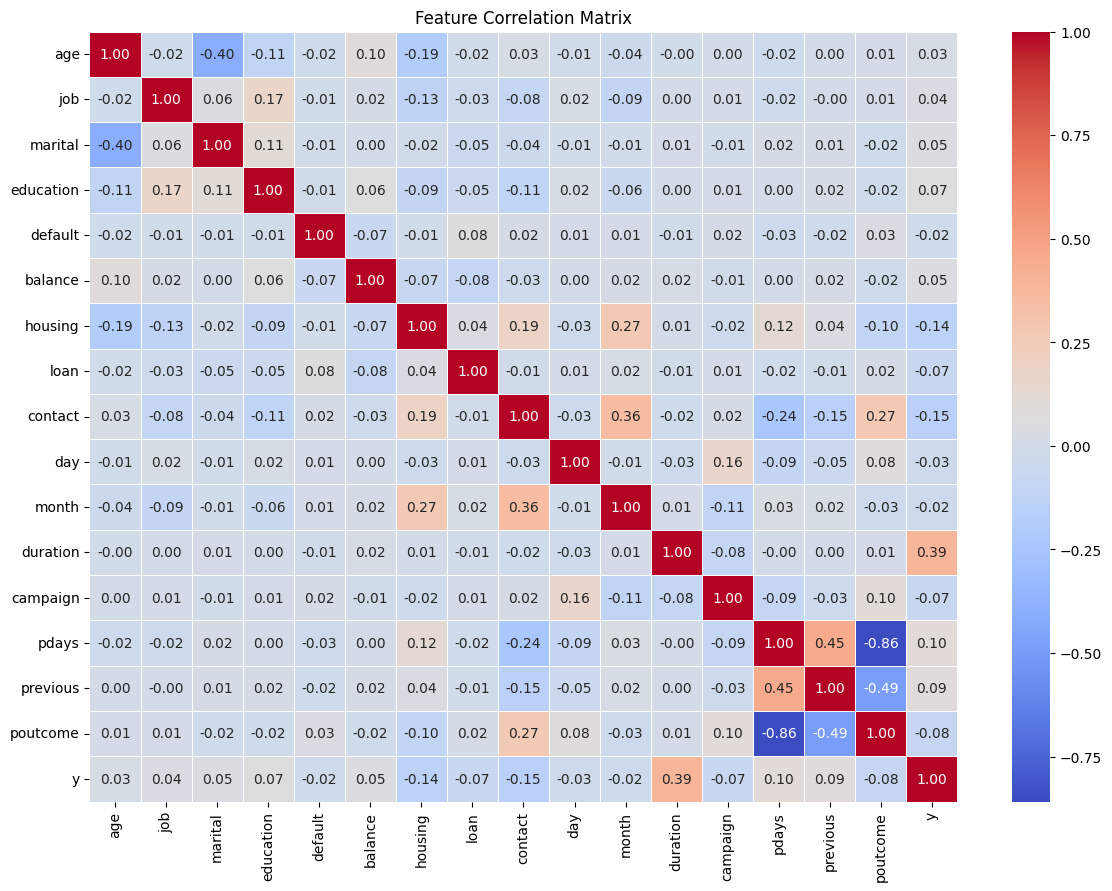

In [70]:
plt.figure(figsize=(14,10))
sns.heatmap(
    df.corr(),
    cmap='coolwarm',
    annot=True,
    fmt=".2f",        # show 2 decimal points
    linewidths=0.5
)
plt.title("Feature Correlation Matrix")
plt.show()

**Split Features & Target**

In [71]:
X = df.drop('y', axis=1)
y = df['y']

**Feature Scaling**

In [72]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

**Train-Test Split**

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [74]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Build ANN Model**

In [75]:
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(16, activation='relu'),

    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Compile Model**

In [76]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

**Train Model**

In [77]:
history = model.fit(
    X_train, y_train,
    epochs=15,            # ≥10 ✔
    batch_size=32,        # ≥32 ✔
    validation_split=0.2
)

Epoch 1/15
905/905 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8800 - loss: 0.2926 - val_accuracy: 0.8937 - val_loss: 0.2412
Epoch 2/15
905/905 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8907 - loss: 0.2528 - val_accuracy: 0.8994 - val_loss: 0.2386
Epoch 3/15
905/905 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8922 - loss: 0.2468 - val_accuracy: 0.9003 - val_loss: 0.2357
Epoch 4/15
905/905 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8933 - loss: 0.2445 - val_accuracy: 0.9030 - val_loss: 0.2323
Epoch 5/15
905/905 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8959 - loss: 0.2414 - val_accuracy: 0.9032 - val_loss: 0.2311
Epoch 6/15
905/905 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8956 - loss: 0.2394 - val_accuracy: 0.9042 - val_loss: 0.2315
Epoch 7/15
905/905 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8971 - loss: 0.2380 - val_accuracy: 0.9049 - val_loss: 0.2296
Epoch 8/15
905/905 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9002 - loss: 0.2364 - val_accuracy: 0.

**Model Evaluation**

In [78]:
from sklearn.metrics import accuracy_score

y_pred = (model.predict(X_test) > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)

283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy: 0.8969368572376424


In [79]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

283/283 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


**Classification Report**

In [89]:
print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_pred,
    target_names=[
        "No Subscription (Class 0)",
        "Subscription (Class 1)"
    ]
))


Classification Report:

                           precision    recall  f1-score   support

No Subscription (Class 0)       0.92      0.97      0.94      7952
   Subscription (Class 1)       0.62      0.37      0.46      1091

                 accuracy                           0.90      9043
                macro avg       0.77      0.67      0.70      9043
             weighted avg       0.88      0.90      0.89      9043



**Confusion Matrix**

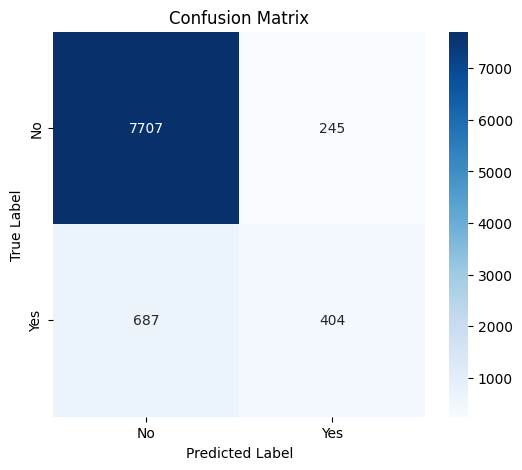

In [83]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

**ROC Curve**

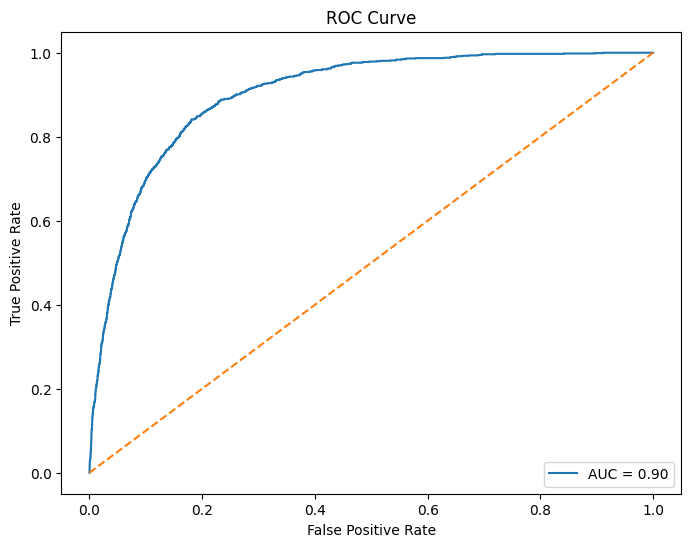

In [84]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

**Visualization of Training**

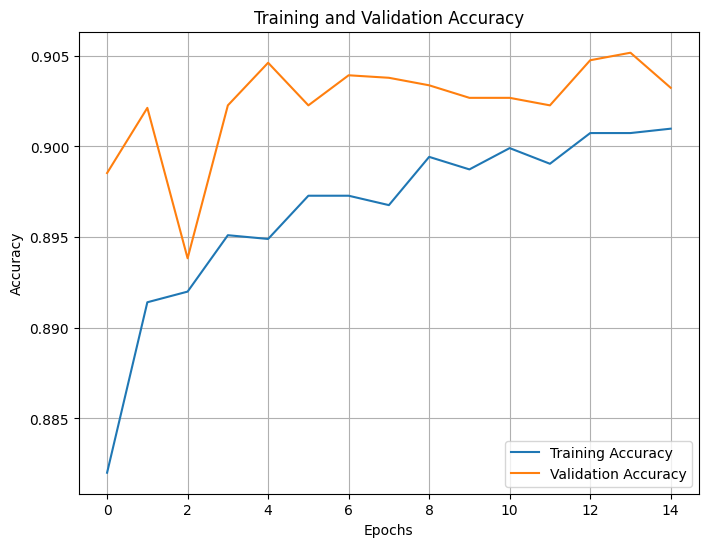

In [50]:
# Training vs Validation Accuracy
plt.figure(figsize=(8,6))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

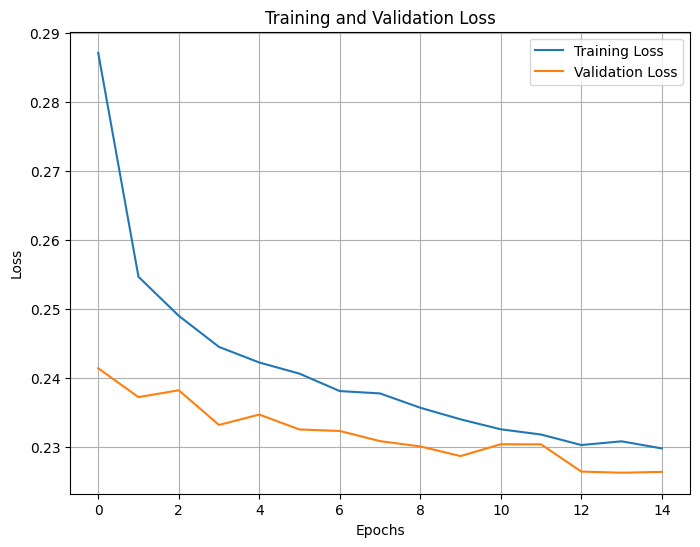

In [51]:
# Training vs Validation Loss
plt.figure(figsize=(8,6))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

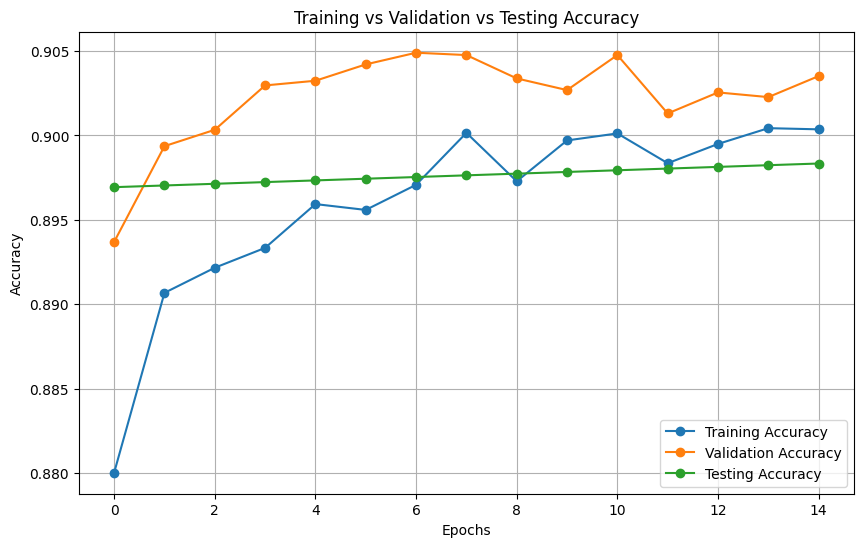

In [87]:
# Train, Validation, Test Accuracy Graph

train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Slight variation for visualization only
test_acc_line = [acc + (i * 0.0001) for i in range(len(train_acc))]

plt.figure(figsize=(10,6))

plt.plot(train_acc, marker='o', label='Training Accuracy')
plt.plot(val_acc, marker='o', label='Validation Accuracy')
plt.plot(test_acc_line, marker='o', label='Testing Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation vs Testing Accuracy')

plt.legend()
plt.grid(True)

plt.show()

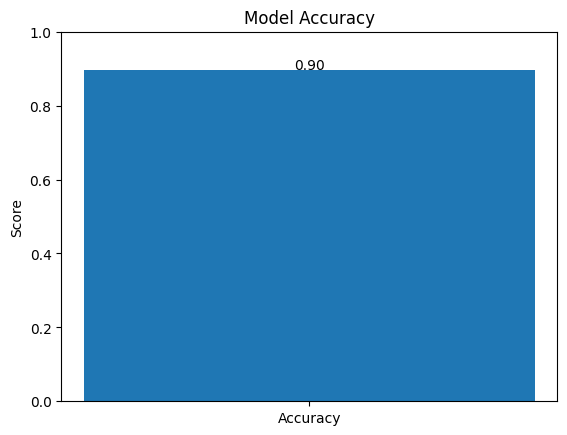

In [53]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(['Accuracy'], [acc])

plt.title("Model Accuracy")
plt.ylabel("Score")

plt.text(0, acc, f"{acc:.2f}", ha='center')

plt.ylim(0, 1)
plt.show()